# Survey "Vektordatenbanken": Explorative Analyse des OpenAlex-Datensatzes

Dieses Notebook analysiert einen Datensatz von **479 wissenschaftlichen Arbeiten** zum Thema
**Vektordatenbanken**, die aus OpenAlex extrahiert und in eine PostgreSQL-Datenbank
(Schema `openalex`) importiert wurden.

**Ziel des Notebooks:**
1. Deskriptive Übersicht über den Datensatz (Umfang, Zeitraum, Publikationstypen)
2. Kategorisierung der Arbeiten nach **Domain → Field → Subfield → Topic**
3. Vertiefte Betrachtung des Fields **Computer Science**
4. Identifikation von **Anwendungsbereichen** außerhalb der Informatik
5. Zitations-, Venue-, Open-Access- und geografische Analyse
6. Ableitung von **Kandidaten für Forschungslücken**

> Hinweis: In der OpenAlex-Taxonomie ist *Computer Science* ein **Field** (nicht Domain) innerhalb
> der Domain *Physical Sciences*. Die Hierarchie lautet: `domain → field → subfield → topic`.


## 0. Setup: Verbindung zur Datenbank

In [22]:
from database.scripts.config import load_config
from database.scripts.connect import connect

# load db config data
config = load_config("database/scripts/database.ini")
# connect to postgres db
conn = connect(config)


Connected to the PostgreSQL server.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from psycopg2.extras import execute_values

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110


## 1. Datensatz laden

Die 479 relevanten `work.id`-Werte werden in eine temporäre Tabelle `target_works` geschrieben.
Dadurch muss die (lange) ID-Liste nicht in jeder Abfrage als `IN (...)`-Klausel wiederholt werden –
alle folgenden Queries joinen einfach gegen `target_works`.


In [24]:
WORK_IDS = ['W1495491215', 'W1500012335', 'W1684369841', 'W1967328652', 'W1987616999', 'W1990158428', 'W1993242035', 'W1997823313', 'W2030925138', 'W2039083336', 'W2046270904', 'W2070627769', 'W2077793746', 'W2094871978', 'W2095789877', 'W2103196687', 'W2108508205', 'W2117970397', 'W2119913432', 'W2244704289', 'W2297811497', 'W2317257828', 'W2531891424', 'W2752706809', 'W2801703976', 'W2803778394', 'W2890554532', 'W2891928281', 'W2906270115', 'W2910163565', 'W2912632784', 'W2944554003', 'W2950013988', 'W2959845550', 'W2998038413', 'W3001417069', 'W3005120054', 'W3035097439', 'W3109592921', 'W3111434830', 'W3134215161', 'W3174800867', 'W3189741760', 'W3207278005', 'W3212666740', 'W4225077961', 'W4226114465', 'W4229454746', 'W4255000078', 'W4310355414', 'W4311519329', 'W4320030387', 'W4366417609', 'W4379511221', 'W4381249050', 'W4382395811', 'W4387258363', 'W4388234781', 'W4388982114', 'W4390647563', 'W4391004470', 'W4391267397', 'W4391849320', 'W4392593432', 'W4393143532', 'W4393183654', 'W4393183699', 'W4393363427', 'W4393621491', 'W4394619840', 'W4394912813', 'W4395038196', 'W4395683878', 'W4396634153', 'W4396655358', 'W4396792104', 'W4396866241', 'W4398251864', 'W4399174623', 'W4399233786', 'W4399323548', 'W4399474238', 'W4399678218', 'W4399794670', 'W4400323029', 'W4400619304', 'W4400732384', 'W4401016840', 'W4401445473', 'W4401778192', 'W4401896515', 'W4401942909', 'W4402042575', 'W4402371950', 'W4402548504', 'W4402584788', 'W4402686428', 'W4402690602', 'W4403074495', 'W4403153405', 'W4403192351', 'W4403276519', 'W4403282600', 'W4403651433', 'W4403776868', 'W4404210426', 'W4404375520', 'W4404555248', 'W4404645544', 'W4404867015', 'W4405106205', 'W4405175171', 'W4405292086', 'W4405379989', 'W4405388744', 'W4405402825', 'W4405763245', 'W4405919385', 'W4405922790', 'W4405963353', 'W4406066774', 'W4406420357', 'W4406613385', 'W4406632839', 'W4406707540', 'W4406993476', 'W4406994660', 'W4407039489', 'W4407056227', 'W4407237143', 'W4407279179', 'W4407349612', 'W4407592210', 'W4407848143', 'W4407959012', 'W4407971929', 'W4408049533', 'W4408069384', 'W4408413603', 'W4408508127', 'W4408764887', 'W4408770536', 'W4408859326', 'W4408892944', 'W4408924242', 'W4408985588', 'W4409147094', 'W4409306920', 'W4409395745', 'W4409396885', 'W4409431455', 'W4409585477', 'W4409675976', 'W4409784633', 'W4409825362', 'W4409940475', 'W4409944279', 'W4409945080', 'W4409958938', 'W4409967668', 'W4410030896', 'W4410046936', 'W4410048693', 'W4410063080', 'W4410069631', 'W4410078500', 'W4410182248', 'W4410242907', 'W4410359057', 'W4410359314', 'W4410374198', 'W4410380288', 'W4410468458', 'W4410470792', 'W4410505925', 'W4410707033', 'W4410918035', 'W4410918923', 'W4410923413', 'W4410924181', 'W4410990060', 'W4411035223', 'W4411105389', 'W4411121655', 'W4411127570', 'W4411243659', 'W4411350044', 'W4411379560', 'W4411403501', 'W4411464649', 'W4411489231', 'W4411491026', 'W4411531405', 'W4411599704', 'W4411644483', 'W4411771462', 'W4411804566', 'W4411905818', 'W4411928761', 'W4412031662', 'W4412063914', 'W4412068710', 'W4412105930', 'W4412112313', 'W4412121390', 'W4412125826', 'W4412352775', 'W4412382969', 'W4412525213', 'W4412546056', 'W4412595718', 'W4412732405', 'W4412870770', 'W4412899694', 'W4412967782', 'W4413078261', 'W4413109814', 'W4413129903', 'W4413224499', 'W4413345394', 'W4413351042', 'W4413399739', 'W4413429496', 'W4413563495', 'W4413763723', 'W4413774906', 'W4413805932', 'W4413822120', 'W4413830359', 'W4413846126', 'W4413939577', 'W4413968235', 'W4414063510', 'W4414116593', 'W4414288073', 'W4414332403', 'W4414352266', 'W4414366807', 'W4414400643', 'W4414410401', 'W4414475265', 'W4414508135', 'W4414544382', 'W4414565035', 'W4414575376', 'W4414621512', 'W4414669346', 'W4414672579', 'W4414718978', 'W4414862569', 'W4415008375', 'W4415030728', 'W4415031233', 'W4415091690', 'W4415124086', 'W4415179176', 'W4415264476', 'W4415352366', 'W4415357927', 'W4415425340', 'W4415560266', 'W4416118075', 'W4416209937', 'W4416296392', 'W4416312014', 'W4416451653', 'W4416508506', 'W4416598713', 'W4416602412', 'W4416941421', 'W4417070313', 'W4417357338', 'W7104100576', 'W7104574964', 'W7106122337', 'W7106512526', 'W7107963063', 'W7108076468', 'W7108940222', 'W7117873744', 'W7117889704', 'W7118180304', 'W7118421099', 'W7118925302', 'W7119501373', 'W7123361798', 'W7124288306', 'W7124987353', 'W7125117678', 'W7125242389', 'W7125409037', 'W7125908171', 'W7126201452', 'W7126210324', 'W7127122676', 'W7127609723', 'W7127961455', 'W7128080678', 'W7128216114', 'W7128424401', 'W7128430305', 'W7128505976', 'W7128519007', 'W7128814359', 'W7129190733', 'W7130506800', 'W7130606713', 'W7131423363', 'W7131615295', 'W7131628730', 'W7134233424', 'W7134234604', 'W7134896751', 'W7134897346', 'W7134915032', 'W7135384646', 'W7138015040', 'W7139092293', 'W7139991652', 'W7140304655', 'W7140704579', 'W7143423157', 'W7147208652', 'W7148786980', 'W7148927217', 'W7149301025', 'W7151453340', 'W7151459201', 'W7151817607', 'W7151843189', 'W7152584678', 'W7154571069', 'W7154596508', 'W7154839046', 'W7155075703', 'W7155175716', 'W7156066800', 'W7159121764', 'W7160279501', 'W7160298117', 'W7160525218', 'W7160603378', 'W7160617460', 'W7160646699', 'W7160700087', 'W7160824525', 'W7160935752', 'W7161013675', 'W7161573164', 'W7161578706', 'W7161600464', 'W7162015458', 'W7162408043', 'W7162491385', 'W7162693109', 'W7162758379', 'W7163881700', 'W7164046778', 'W7164147187', 'W7164338188', 'W7164403289', 'W7164495097', 'W7164742938', 'W7164821161', 'W7164836010', 'W7164861125', 'W7164992634', 'W7165029640', 'W7165358865', 'W7165740724', 'W7166573544', 'W7166653481', 'W7167092418', 'W7167489886', 'W7167570425', 'W7167670355', 'W7167845799', 'W7167851908', 'W7167897216', 'W7167924274', 'W7168186229', 'W7168284826', 'W7168362781', 'W7168442217', 'W7168512404', 'W7169671164', 'W7169727378', 'W7170569605', 'W7171494850', 'W1508188319', 'W1528111169', 'W1849674298', 'W1894620164', 'W1974948045', 'W1998032829', 'W2011313178', 'W2019695274', 'W2021236715', 'W2026383861', 'W2036127775', 'W2046515937', 'W2054387564', 'W2063926948', 'W2068469762', 'W2093291249', 'W2105762073', 'W2107876039', 'W2160561537', 'W2162001642', 'W2187672001', 'W2187836080', 'W2282908197', 'W2293446003', 'W2338162861', 'W2401640580', 'W2560478127', 'W2586054446', 'W2768524606', 'W2773430425', 'W2785343180', 'W4283384464', 'W4310363171', 'W4312285477', 'W4389573668', 'W4390692351', 'W4390913691', 'W4392631937', 'W4400641571', 'W4401669218', 'W4402308794', 'W4404181035', 'W4404181049', 'W4404181126', 'W4404181268', 'W4404181272', 'W4405541555', 'W4405541605', 'W4407189389', 'W4407355496', 'W4407357002', 'W4409561035', 'W4409581432', 'W4410538599', 'W4410638971', 'W4411277297', 'W4411403284', 'W4411403474', 'W4411643664', 'W4411870291', 'W4411936524', 'W4412692590', 'W4413755895', 'W4413926018', 'W4413980395', 'W4413980656', 'W4413985475', 'W4414241804', 'W4414266937', 'W4414267107', 'W4414267113', 'W4416994072', 'W7108994786', 'W7115173192', 'W7127138745', 'W7127191332', 'W7138897806', 'W7138958097', 'W7147125823', 'W7147668907', 'W7153544824', 'W7161587223', 'W7162770757', 'W7163994313', 'W7164008069', 'W7164663719', 'W7164993460', 'W7166800845', 'W7167919148', 'W7170028651']

print(f"Anzahl geladener Work-IDs: {len(WORK_IDS)}")

with conn.cursor() as cur:
    cur.execute("DROP TABLE IF EXISTS target_works;")
    cur.execute("CREATE TEMP TABLE target_works (work_id VARCHAR PRIMARY KEY);")
    execute_values(cur, "INSERT INTO target_works (work_id) VALUES %s", [(wid,) for wid in WORK_IDS])
conn.commit()


Anzahl geladener Work-IDs: 479


## 2. Deskriptive Übersicht

Grundlegende Kennzahlen: Größe des Datensatzes, Zeitraum, durchschnittliche Zitationen,
Open-Access-Anteil und Anteil retrahierter Arbeiten.


In [25]:
query_overview = '''
SELECT
    COUNT(*) AS total_works,
    MIN(publication_year) AS earliest_year,
    MAX(publication_year) AS latest_year,
    ROUND(AVG(cited_by_count)::numeric, 2) AS avg_citations,
    MAX(cited_by_count) AS max_citations,
    SUM(CASE WHEN is_open_access THEN 1 ELSE 0 END) AS oa_count,
    ROUND(100.0 * SUM(CASE WHEN is_open_access THEN 1 ELSE 0 END) / COUNT(*), 1) AS oa_share_pct,
    SUM(CASE WHEN is_retracted THEN 1 ELSE 0 END) AS retracted_count
FROM openalex.work w
JOIN target_works tw ON tw.work_id = w.id;
'''
df_overview = pd.read_sql(query_overview, conn)
df_overview


,total_works,earliest_year,latest_year,avg_citations,max_citations,oa_count,oa_share_pct,retracted_count
0,479,1990,2026,8.24,1171,389,81.2,0


### Verteilung nach Publikationstyp (`work_type`)

Zeigt, wie sich der Datensatz auf Artikel, Preprints, Konferenzbeiträge etc. verteilt. Ein hoher
Preprint-Anteil deutet auf ein sehr aktives, sich schnell entwickelndes Forschungsfeld hin.


,work_type,n
0,"Original, citable research usually in a journal, including full research papers, brief communications, technical not...",479


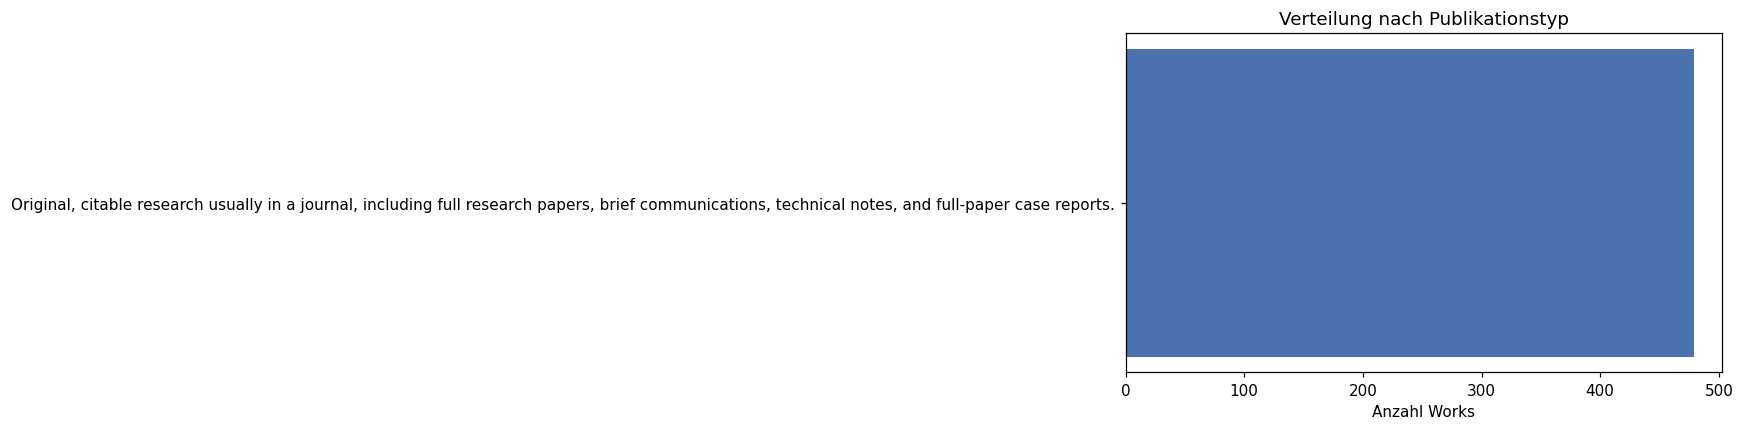

In [26]:
query_worktype = '''
SELECT COALESCE(wt.display_description, 'unbekannt') AS work_type, COUNT(*) AS n
FROM openalex.work w
JOIN target_works tw ON tw.work_id = w.id
LEFT JOIN openalex.work_type wt ON wt.id = w.type_id
GROUP BY wt.display_description
ORDER BY n DESC;
'''
df_worktype = pd.read_sql(query_worktype, conn)
display(df_worktype)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(df_worktype["work_type"], df_worktype["n"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Works")
ax.set_title("Verteilung nach Publikationstyp")
plt.tight_layout()
plt.show()


## 3. Publikationstrend über die Zeit

Anzahl der Publikationen pro Jahr – zentraler Indikator für das Wachstum/die Reife des
Forschungsfelds "Vektordatenbanken".


,publication_year,n,cumulative
0,1990,1,1
1,1991,1,2
2,1996,2,4
3,1997,1,5
4,2000,2,7
5,2004,1,8
6,2005,2,10
7,2006,1,11
8,2007,1,12
9,2008,1,13


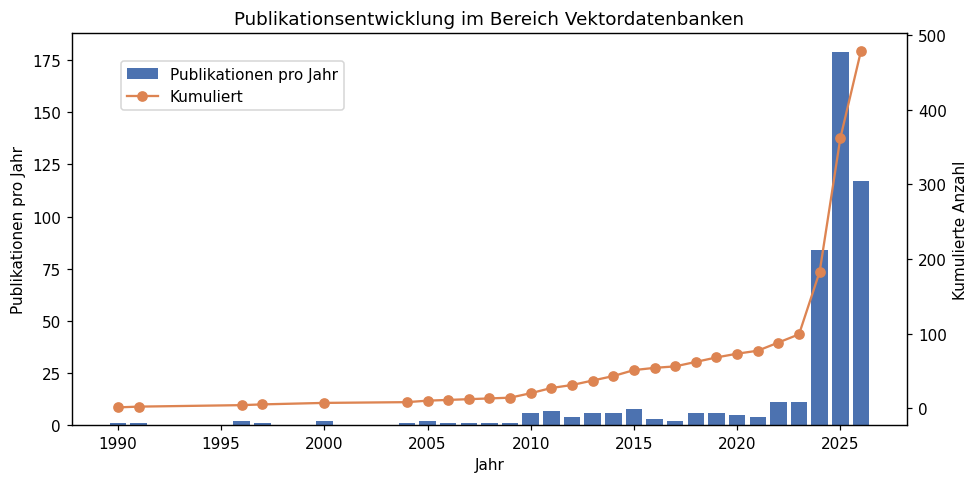

In [27]:
query_trend = '''
SELECT publication_year, COUNT(*) AS n
FROM openalex.work w
JOIN target_works tw ON tw.work_id = w.id
WHERE publication_year IS NOT NULL
GROUP BY publication_year
ORDER BY publication_year;
'''
df_trend = pd.read_sql(query_trend, conn)
df_trend["cumulative"] = df_trend["n"].cumsum()
display(df_trend)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(df_trend["publication_year"], df_trend["n"], color="#4C72B0", label="Publikationen pro Jahr")
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Publikationen pro Jahr")
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2 = ax1.twinx()
ax2.plot(df_trend["publication_year"], df_trend["cumulative"], color="#DD8452", marker="o", label="Kumuliert")
ax2.set_ylabel("Kumulierte Anzahl")

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.title("Publikationsentwicklung im Bereich Vektordatenbanken")
plt.tight_layout()
plt.show()


> **Hinweis zur Interpretation:** Ein starker Anstieg in den letzten 1–2 Jahren, kombiniert mit
> einem hohen Preprint-Anteil (siehe oben), ist typisch für ein Feld, das sich noch in der
> Konsolidierungsphase befindet – relevant für die Einordnung, wie "reif" die Forschung zu
> Vektordatenbanken aktuell ist.


## 4. Taxonomische Kategorisierung: Domain-Ebene

Für die Kategorisierung wird pro Work das **Primary Topic** verwendet (das Topic mit dem höchsten
`score` in `work_topic`). Jedes Work wird so genau einer Domain/einem Field/Subfield/Topic
zugeordnet. Das vermeidet Mehrfachzählungen, die entstünden, wenn man alle zugeordneten Topics
eines Works gleichzeitig zählen würde.


,domain,n
0,Physical Sciences,361
1,Social Sciences,82
2,Health Sciences,22
3,Life Sciences,14


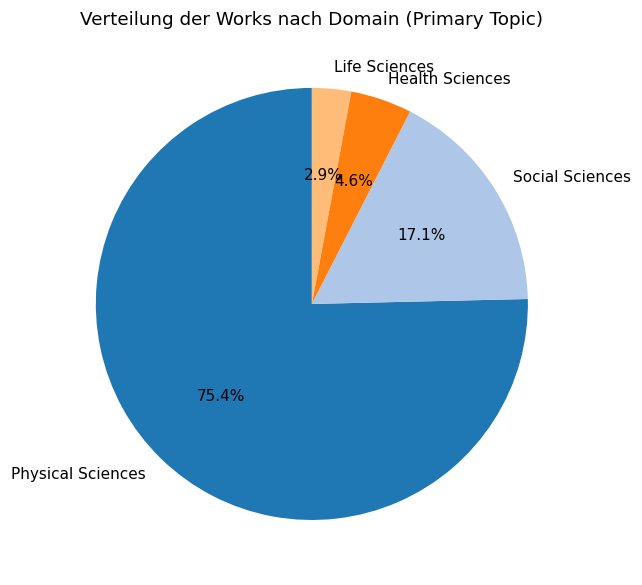

In [28]:
query_domain = '''
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM openalex.work_topic wt
    JOIN target_works tw ON tw.work_id = wt.work_id
    ORDER BY wt.work_id, wt.score DESC
)
SELECT d.display_name AS domain, COUNT(*) AS n
FROM primary_topic pt
JOIN openalex.topic t ON t.id = pt.topic_id
JOIN openalex.subfield sf ON sf.id = t.subfield_id
JOIN openalex.field f ON f.id = sf.field_id
JOIN openalex.domain d ON d.id = f.domain_id
GROUP BY d.display_name
ORDER BY n DESC;
'''
df_domain = pd.read_sql(query_domain, conn)
display(df_domain)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(df_domain["n"], labels=df_domain["domain"], autopct="%1.1f%%", startangle=90,
       colors=plt.cm.tab20.colors)
ax.set_title("Verteilung der Works nach Domain (Primary Topic)")
plt.tight_layout()
plt.show()


## 5. Taxonomische Kategorisierung: Field-Ebene

Verteilung über alle Fields (Top 15), um zu quantifizieren, wie groß der Anteil von
**Computer Science** tatsächlich am Gesamtdatensatz ist – und welche anderen Fields relevant sind.


,field,n
0,Computer Science,291
1,Engineering,37
2,Social Sciences,34
3,Environmental Science,24
4,"Business, Management and Accounting",21
5,Medicine,20
6,Decision Sciences,18
7,"Biochemistry, Genetics and Molecular Biology",9
8,Earth and Planetary Sciences,5
9,Psychology,4


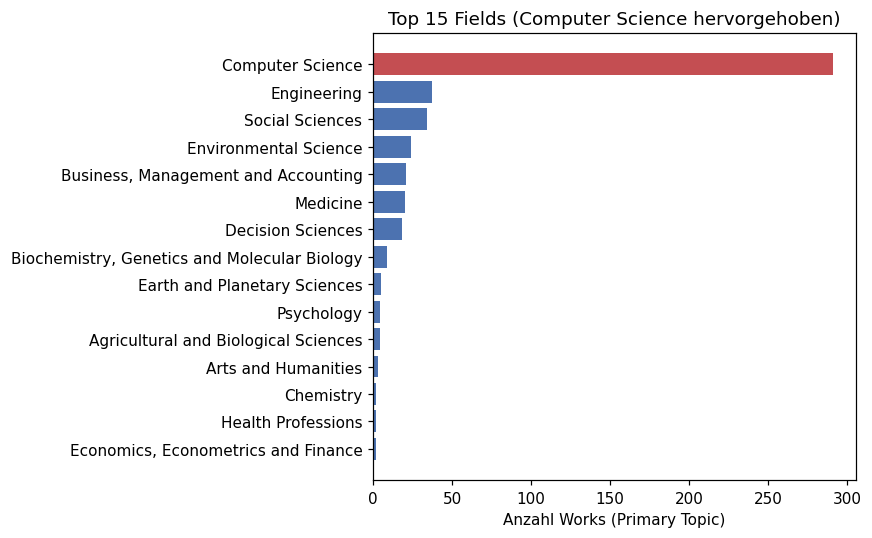

In [29]:
query_field = '''
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM openalex.work_topic wt
    JOIN target_works tw ON tw.work_id = wt.work_id
    ORDER BY wt.work_id, wt.score DESC
)
SELECT f.display_name AS field, COUNT(*) AS n
FROM primary_topic pt
JOIN openalex.topic t ON t.id = pt.topic_id
JOIN openalex.subfield sf ON sf.id = t.subfield_id
JOIN openalex.field f ON f.id = sf.field_id
GROUP BY f.display_name
ORDER BY n DESC
LIMIT 15;
'''
df_field = pd.read_sql(query_field, conn)
display(df_field)

colors = ["#C44E52" if f == "Computer Science" else "#4C72B0" for f in df_field["field"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_field["field"], df_field["n"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Anzahl Works (Primary Topic)")
ax.set_title("Top 15 Fields (Computer Science hervorgehoben)")
plt.tight_layout()
plt.show()


## 6. Vertiefung: Computer Science – Subfields

Innerhalb des Fields *Computer Science* wird nun aufgeschlüsselt, welche Subfields
(z. B. Information Systems, Artificial Intelligence, Computer Networks and Communications)
vertreten sind.


,subfield,n
0,Artificial Intelligence,121
1,Computer Vision and Pattern Recognition,70
2,Information Systems,40
3,Computer Networks and Communications,29
4,Signal Processing,18
5,Computer Science Applications,4
6,Software,3
7,Hardware and Architecture,3
8,Human-Computer Interaction,1
9,Computational Theory and Mathematics,1


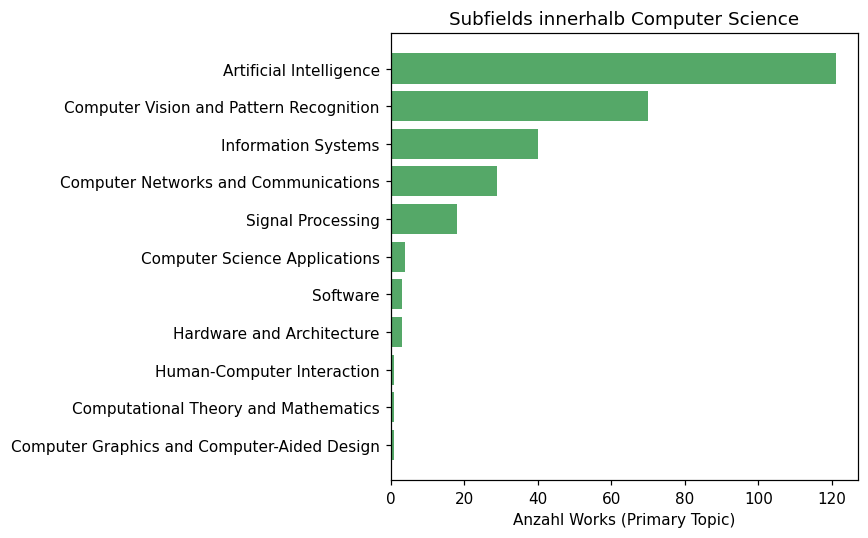

In [30]:
query_cs_subfield = '''
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM openalex.work_topic wt
    JOIN target_works tw ON tw.work_id = wt.work_id
    ORDER BY wt.work_id, wt.score DESC
)
SELECT sf.display_name AS subfield, COUNT(*) AS n
FROM primary_topic pt
JOIN openalex.topic t ON t.id = pt.topic_id
JOIN openalex.subfield sf ON sf.id = t.subfield_id
JOIN openalex.field f ON f.id = sf.field_id
WHERE f.display_name = 'Computer Science'
GROUP BY sf.display_name
ORDER BY n DESC;
'''
df_cs_subfield = pd.read_sql(query_cs_subfield, conn)
display(df_cs_subfield)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_cs_subfield["subfield"], df_cs_subfield["n"], color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Works (Primary Topic)")
ax.set_title("Subfields innerhalb Computer Science")
plt.tight_layout()
plt.show()


## 7. Vertiefung: Computer Science – Top Topics

Hier werden **alle** Topic-Zuordnungen (nicht nur das Primary Topic) berücksichtigt, die zum
Field *Computer Science* gehören. Das liefert ein feingranulareres Bild der konkreten
Teilbereiche (z. B. Information Retrieval, Approximate Nearest Neighbor Search, Databases),
in denen Vektordatenbanken diskutiert werden.


,topic,subfield,n_works,avg_score
0,Topic Modeling,Artificial Intelligence,78,0.605
1,Advanced Image and Video Retrieval Techniques,Computer Vision and Pattern Recognition,55,0.843
2,Data Management and Algorithms,Signal Processing,44,0.791
3,Image Retrieval and Classification Techniques,Computer Vision and Pattern Recognition,31,0.888
4,AI in Service Interactions,Artificial Intelligence,30,0.487
5,Advanced Database Systems and Queries,Computer Networks and Communications,27,0.623
6,Natural Language Processing Techniques,Artificial Intelligence,22,0.810
7,Algorithms and Data Compression,Artificial Intelligence,17,0.952
8,Machine Learning in Healthcare,Artificial Intelligence,17,0.610
9,Semantic Web and Ontologies,Artificial Intelligence,16,0.765


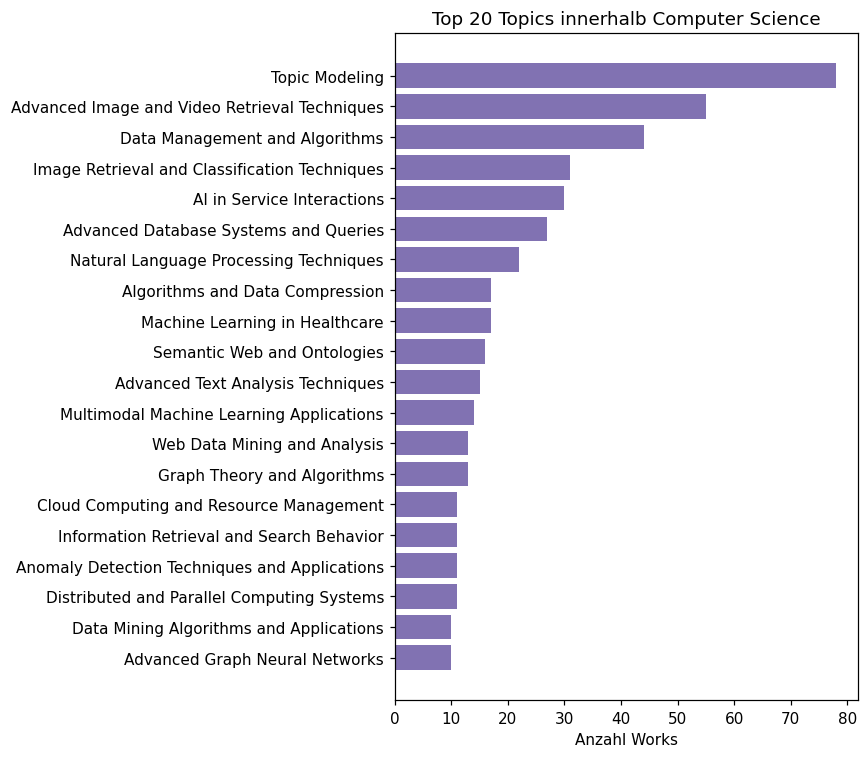

In [31]:
query_cs_topics = '''
SELECT t.display_name AS topic, sf.display_name AS subfield,
       COUNT(DISTINCT wt.work_id) AS n_works,
       ROUND(AVG(wt.score)::numeric, 3) AS avg_score
FROM openalex.work_topic wt
JOIN target_works tw ON tw.work_id = wt.work_id
JOIN openalex.topic t ON t.id = wt.topic_id
JOIN openalex.subfield sf ON sf.id = t.subfield_id
JOIN openalex.field f ON f.id = sf.field_id
WHERE f.display_name = 'Computer Science'
GROUP BY t.display_name, sf.display_name
ORDER BY n_works DESC
LIMIT 20;
'''
df_cs_topics = pd.read_sql(query_cs_topics, conn)
display(df_cs_topics)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(df_cs_topics["topic"], df_cs_topics["n_works"], color="#8172B2")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Works")
ax.set_title("Top 20 Topics innerhalb Computer Science")
plt.tight_layout()
plt.show()


## 8. Zeitliche Entwicklung der CS-Topics

Für die wichtigsten CS-Topics wird die jährliche Verteilung betrachtet. Das hilft,
**aufstrebende** Themen (steigende Kurve, v. a. in den letzten Jahren) von **stagnierenden oder
"verlassenen"** Themen zu unterscheiden – ein wichtiger Baustein für die spätere
Gap-Analyse (Abschnitt 12).


topic,AI in Service Interactions,Advanced Database Systems and Queries,Advanced Image and Video Retrieval Techniques,Algorithms and Data Compression,Data Management and Algorithms,Image Retrieval and Classification Techniques,Natural Language Processing Techniques,Topic Modeling
publication_year,,,,,,,,
1996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1997,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2010,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
2011,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2012,0.0,0.0,1.0,0.0,2.0,1.0,0.0,0.0
2013,0.0,1.0,5.0,1.0,1.0,5.0,0.0,0.0
2014,0.0,0.0,3.0,0.0,1.0,3.0,0.0,0.0
2015,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


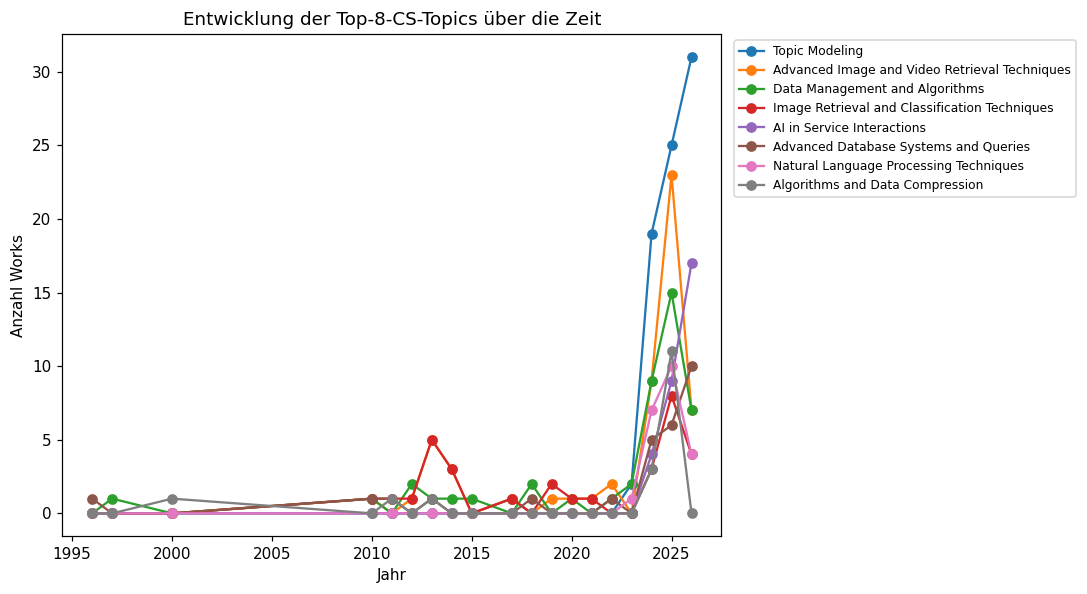

In [32]:
query_cs_topic_trend = '''
SELECT w.publication_year, t.display_name AS topic, COUNT(DISTINCT wt.work_id) AS n
FROM openalex.work_topic wt
JOIN target_works tw ON tw.work_id = wt.work_id
JOIN openalex.work w ON w.id = wt.work_id
JOIN openalex.topic t ON t.id = wt.topic_id
JOIN openalex.subfield sf ON sf.id = t.subfield_id
JOIN openalex.field f ON f.id = sf.field_id
WHERE f.display_name = 'Computer Science' AND w.publication_year IS NOT NULL
GROUP BY w.publication_year, t.display_name
ORDER BY w.publication_year;
'''
df_cs_topic_trend = pd.read_sql(query_cs_topic_trend, conn)

top_topics = df_cs_topics["topic"].head(8).tolist()
pivot = (df_cs_topic_trend[df_cs_topic_trend["topic"].isin(top_topics)]
         .pivot_table(index="publication_year", columns="topic", values="n", fill_value=0))
display(pivot)

fig, ax = plt.subplots(figsize=(10, 5.5))
for topic in top_topics:
    if topic in pivot.columns:
        ax.plot(pivot.index, pivot[topic], marker="o", label=topic)
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl Works")
ax.set_title("Entwicklung der Top-8-CS-Topics über die Zeit")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()


## 9. Anwendungsbereiche außerhalb Computer Science

Um die Frage "In welchen Bereichen werden Vektordatenbanken eingesetzt?" über die Informatik
hinaus zu beantworten, werden hier alle Works betrachtet, deren **Primary Topic** einem anderen
Field als Computer Science zugeordnet ist (z. B. Medizin, Biologie, Wirtschaft, Sozialwissenschaften).


,domain,field,n
0,Physical Sciences,Engineering,37
1,Social Sciences,Social Sciences,34
2,Physical Sciences,Environmental Science,24
3,Social Sciences,"Business, Management and Accounting",21
4,Health Sciences,Medicine,20
5,Social Sciences,Decision Sciences,18
6,Life Sciences,"Biochemistry, Genetics and Molecular Biology",9
7,Physical Sciences,Earth and Planetary Sciences,5
8,Social Sciences,Psychology,4
9,Life Sciences,Agricultural and Biological Sciences,4


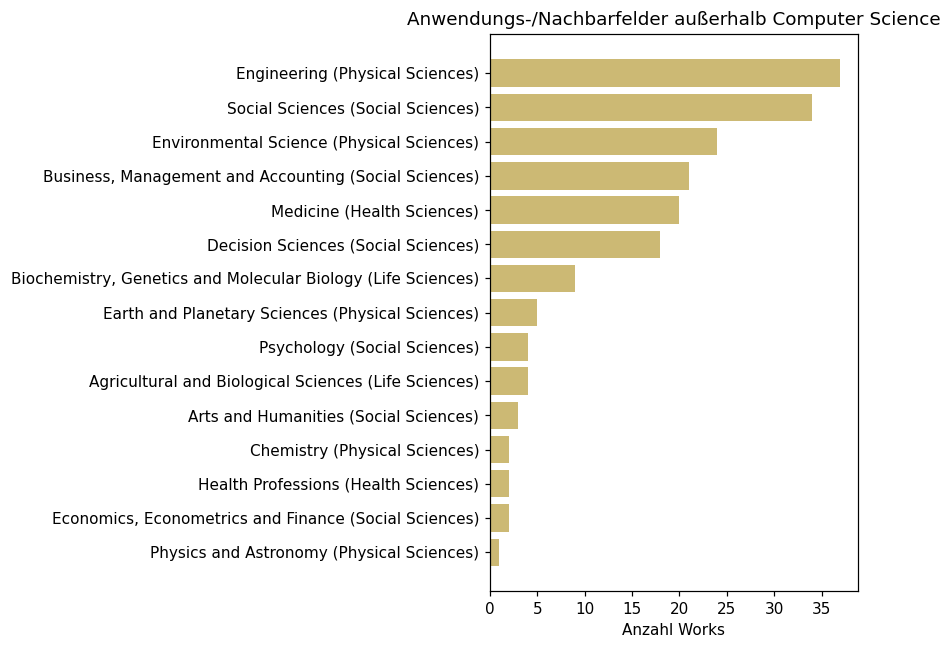

In [33]:
query_non_cs = '''
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM openalex.work_topic wt
    JOIN target_works tw ON tw.work_id = wt.work_id
    ORDER BY wt.work_id, wt.score DESC
)
SELECT d.display_name AS domain, f.display_name AS field, COUNT(*) AS n
FROM primary_topic pt
JOIN openalex.topic t ON t.id = pt.topic_id
JOIN openalex.subfield sf ON sf.id = t.subfield_id
JOIN openalex.field f ON f.id = sf.field_id
JOIN openalex.domain d ON d.id = f.domain_id
WHERE f.display_name <> 'Computer Science'
GROUP BY d.display_name, f.display_name
ORDER BY n DESC
LIMIT 15;
'''
df_non_cs = pd.read_sql(query_non_cs, conn)
display(df_non_cs)

fig, ax = plt.subplots(figsize=(8, 6))
labels = df_non_cs["field"] + " (" + df_non_cs["domain"] + ")"
ax.barh(labels, df_non_cs["n"], color="#CCB974")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Works")
ax.set_title("Anwendungs-/Nachbarfelder außerhalb Computer Science")
plt.tight_layout()
plt.show()


## 10. Keyword-Analyse

Ergänzend zur Topic-Taxonomie liefern die freien `keyword`-Zuordnungen konkretere,
anwendungsnahe Begriffe (z. B. spezifische Systemnamen, Domänenbegriffe), die in der
Topic-Hierarchie u. U. nicht sichtbar werden.


,keyword,n,avg_score
0,Computer science,273,0.588
1,Artificial intelligence,144,0.380
2,Information retrieval,83,0.432
3,Database,80,0.469
4,Geography,57,0.312
5,Data mining,55,0.416
6,Context (archaeology),49,0.538
7,Mathematics,49,0.238
8,World Wide Web,40,0.327
9,Pattern recognition (psychology),39,0.490


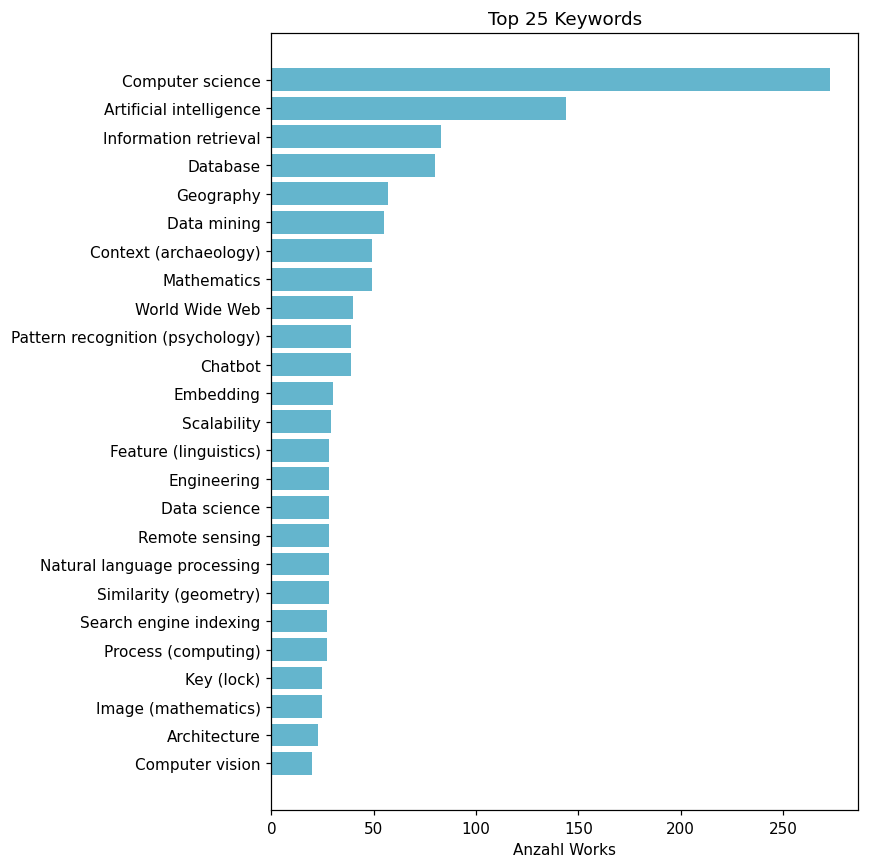

In [34]:
query_keywords = '''
SELECT k.display_name AS keyword, COUNT(*) AS n, ROUND(AVG(wk.score)::numeric, 3) AS avg_score
FROM openalex.work_keyword wk
JOIN target_works tw ON tw.work_id = wk.work_id
JOIN openalex.keyword k ON k.id = wk.keyword_id
GROUP BY k.display_name
ORDER BY n DESC
LIMIT 25;
'''
df_keywords = pd.read_sql(query_keywords, conn)
display(df_keywords)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(df_keywords["keyword"], df_keywords["n"], color="#64B5CD")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Works")
ax.set_title("Top 25 Keywords")
plt.tight_layout()
plt.show()


## 11. Zitations- und Venue-Analyse

**a) Meistzitierte Arbeiten** – potenzielle Grundlagen-/Schlüsselarbeiten für das Survey.
**b) Verteilung der Zitationszahlen** – Log-Skala, da Zitationsverteilungen typischerweise stark
rechtsschief sind.
**c) Publikationsorte** (`source_type`) und **Open-Access-Anteil**.


In [35]:
query_top_cited = '''
SELECT w.id, w.title, w.publication_year, w.cited_by_count
FROM openalex.work w
JOIN target_works tw ON tw.work_id = w.id
ORDER BY w.cited_by_count DESC NULLS LAST
LIMIT 15;
'''
df_top_cited = pd.read_sql(query_top_cited, conn)
df_top_cited


,id,title,publication_year,cited_by_count
0,W2036127775,Bilbao Crystallographic Server: I. Databases and crystallographic computing programs,2005,1171
1,W4415124086,The Faiss Library,2025,245
2,W2160561537,Computing continuous sky view factors using 3D urban raster and vector databases: comparison and application to urba...,2008,216
3,W2119913432,Approximate Nearest Neighbor Search by Residual Vector Quantization,2010,162
4,W2282908197,Observed Tropical Cyclone Size Revisited,2016,148
5,W4400641571,Survey of vector database management systems,2024,102
6,W2752706809,Assessing the relationship between sky view factor and land surface temperature to the spatial resolution,2017,99
7,W1990158428,Nigeria Anopheles Vector Database: An Overview of 100 Years' Research,2011,83
8,W4391849320,"Vector database management systems: Fundamental concepts, use-cases, and current challenges",2024,77
9,W4312285477,Manu,2022,71


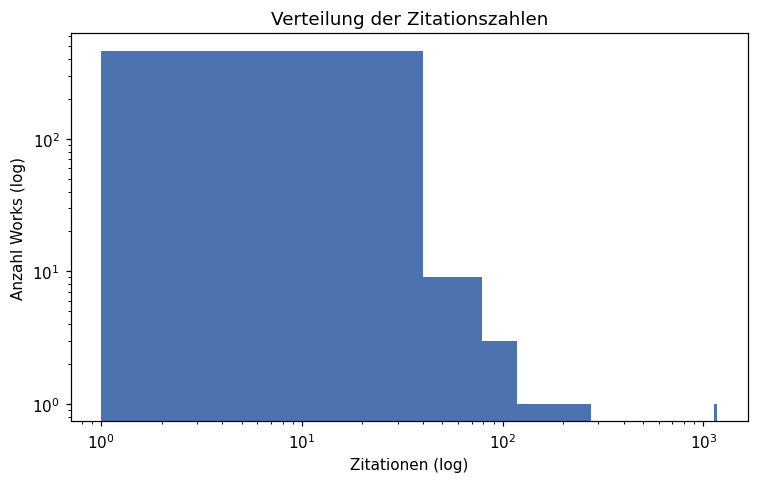

In [36]:
query_citations = '''
SELECT w.cited_by_count
FROM openalex.work w
JOIN target_works tw ON tw.work_id = w.id
WHERE w.cited_by_count IS NOT NULL;
'''
df_citations = pd.read_sql(query_citations, conn)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df_citations["cited_by_count"].clip(lower=1), bins=30, color="#4C72B0")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Zitationen (log)")
ax.set_ylabel("Anzahl Works (log)")
ax.set_title("Verteilung der Zitationszahlen")
plt.tight_layout()
plt.show()


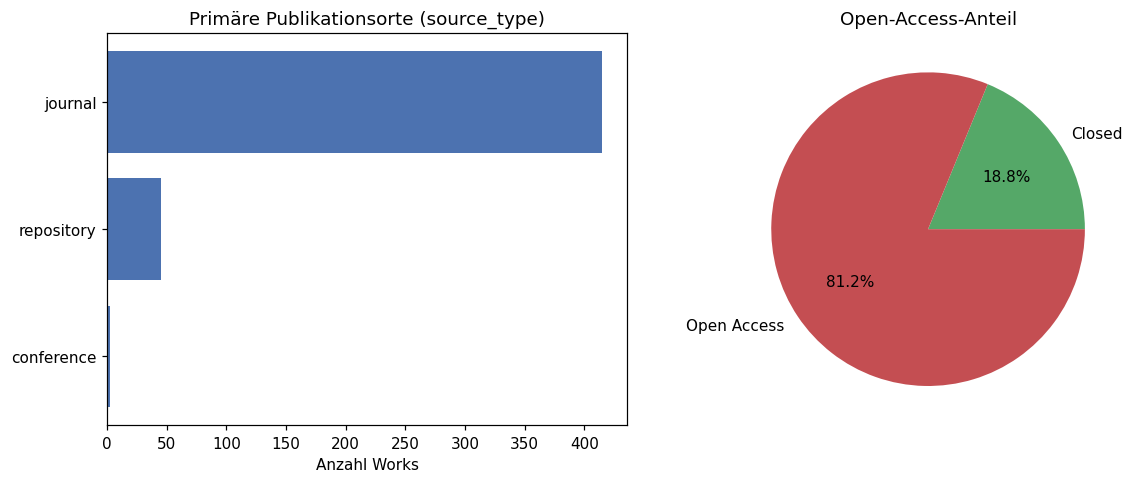

,source_type,n
0,journal,415
1,repository,45
2,conference,2


,is_open_access,n
0,False,90
1,True,389


In [37]:
query_source_type = '''
SELECT st.display_name AS source_type, COUNT(*) AS n
FROM openalex.work_locations wl
JOIN target_works tw ON tw.work_id = wl.work_id
JOIN openalex.locations l ON l.id = wl.locations_id
JOIN openalex.source s ON s.id = l.source_id
JOIN openalex.source_type st ON st.id = s.source_type_id
WHERE wl.is_primary = true
GROUP BY st.display_name
ORDER BY n DESC;
'''
df_source_type = pd.read_sql(query_source_type, conn)

query_oa = '''
SELECT is_open_access, COUNT(*) AS n
FROM openalex.work w
JOIN target_works tw ON tw.work_id = w.id
GROUP BY is_open_access;
'''
df_oa = pd.read_sql(query_oa, conn)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(df_source_type["source_type"], df_source_type["n"], color="#4C72B0")
axes[0].invert_yaxis()
axes[0].set_title("Primäre Publikationsorte (source_type)")
axes[0].set_xlabel("Anzahl Works")

axes[1].pie(df_oa["n"], labels=df_oa["is_open_access"].map({True: "Open Access", False: "Closed"}),
            autopct="%1.1f%%", colors=["#55A868", "#C44E52"])
axes[1].set_title("Open-Access-Anteil")
plt.tight_layout()
plt.show()

display(df_source_type)
display(df_oa)


## 12. Geografische Verteilung

Zählt, aus wie vielen Works mindestens ein Autor mit einer Institution aus dem jeweiligen Land
beteiligt ist. Zeigt geografische Schwerpunkte (und implizit unterrepräsentierte Regionen) der
Forschung zu Vektordatenbanken.


,country,n_works
0,United States,98
1,China,82
2,India,50
3,United Kingdom,17
4,"Korea, Republic of",16
5,France,12
6,Spain,11
7,Italy,10
8,Turkey,9
9,Germany,8


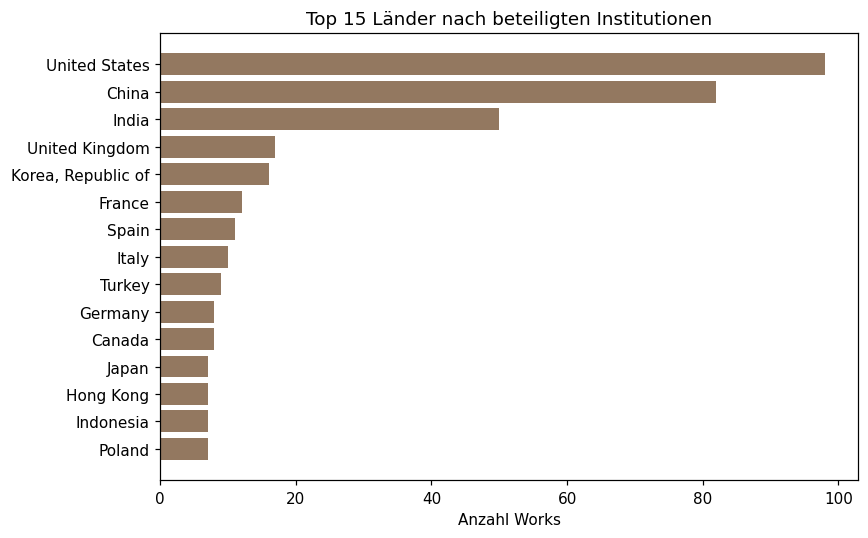

In [38]:
query_country = '''
SELECT c.display_name AS country, COUNT(DISTINCT wai.work_id) AS n_works
FROM openalex.work_author_institution wai
JOIN target_works tw ON tw.work_id = wai.work_id
JOIN openalex.institution i ON i.id = wai.institution_id
JOIN openalex.country c ON c.code_alpha_2 = i.country_code_alpha_2
GROUP BY c.display_name
ORDER BY n_works DESC
LIMIT 15;
'''
df_country = pd.read_sql(query_country, conn)
display(df_country)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_country["country"], df_country["n_works"], color="#937860")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Works")
ax.set_title("Top 15 Länder nach beteiligten Institutionen")
plt.tight_layout()
plt.show()


## 12b. Fokus DACH-Region

Kurzer Blick darauf, ob und wie stark Deutschland, Österreich und die Schweiz im Datensatz
vertreten sind – ggf. relevant für die Einordnung der eigenen Arbeit im deutschsprachigen Diskurs.


In [39]:
dach = df_country[df_country["country"].isin(["Germany", "Austria", "Switzerland"])]
display(dach if not dach.empty else "Keine DACH-Länder unter den Top 15 – ggf. Abfrage ohne LIMIT erneut ausführen.")


,country,n_works
9,Germany,8


## 13. Forschungslücken: Kandidaten

Auf Basis der vorherigen Analysen werden hier automatisiert Kandidaten für Forschungslücken
zusammengestellt:

- **Unterrepräsentierte CS-Subfields**: Subfields mit sehr wenigen Works (Primary Topic).
- **Nicht mehr aktive Topics**: Topics, die in der ersten Hälfte des Beobachtungszeitraums
  auftraten, in den letzten 2 Jahren des Datensatzes aber nicht mehr.
- **Randständige Anwendungsfelder**: Fields außerhalb CS mit nur 1–2 Works – mögliche
  unterexplorierte Einsatzgebiete für Vektordatenbanken.

Diese Listen ersetzen keine inhaltliche Prüfung, sind aber ein guter Ausgangspunkt, um im
Volltext gezielt nachzusehen, *warum* ein Bereich so schwach vertreten ist (z. B. weil er
tatsächlich neu/unerforscht ist, oder weil er in dieser OpenAlex-Stichprobe nur zufällig
unterrepräsentiert ist).


In [40]:
# a) Unterrepräsentierte CS-Subfields (<= 3 Works, Primary Topic)
low_subfields = df_cs_subfield[df_cs_subfield["n"] <= 3]
print("Unterrepräsentierte CS-Subfields (<=3 Works):")
display(low_subfields)


Unterrepräsentierte CS-Subfields (<=3 Works):


,subfield,n
6,Software,3
7,Hardware and Architecture,3
8,Human-Computer Interaction,1
9,Computational Theory and Mathematics,1
10,Computer Graphics and Computer-Aided Design,1


In [41]:
# b) Topics ohne Aktivität in den letzten 2 Jahren des Datensatzes
last_year = int(df_trend["publication_year"].max())
first_half_cutoff = int(df_trend["publication_year"].median())

activity = df_cs_topic_trend.groupby("topic")["publication_year"].agg(["min", "max", "sum"]).reset_index()
inactive_recent = activity[
    (activity["min"] <= first_half_cutoff) & (activity["max"] < last_year - 1)
].sort_values("max")

print(f"Letztes Jahr im Datensatz: {last_year} | Cutoff erste Hälfte: {first_half_cutoff}")
print("CS-Topics ohne Aktivität in den letzten 2 Jahren, obwohl früh im Zeitraum vorhanden:")
display(inactive_recent)


Letztes Jahr im Datensatz: 2026 | Cutoff erste Hälfte: 2012
CS-Topics ohne Aktivität in den letzten 2 Jahren, obwohl früh im Zeitraum vorhanden:


,topic,min,max,sum
136,Web Applications and Data Management,1997,1997,1997
29,Computational Drug Discovery Methods,2005,2005,2005
5,Advanced Data Compression Techniques,2012,2024,6049


In [42]:
# c) Randständige Anwendungsfelder außerhalb CS (<=2 Works)
fringe_fields = df_non_cs[df_non_cs["n"] <= 2]
print("Randständige Anwendungsfelder (<=2 Works):")
display(fringe_fields)


Randständige Anwendungsfelder (<=2 Works):


,domain,field,n
11,Physical Sciences,Chemistry,2
12,Health Sciences,Health Professions,2
13,Social Sciences,"Economics, Econometrics and Finance",2
14,Physical Sciences,Physics and Astronomy,1


## 14. Zusammenfassung

Diese Analysen liefern die quantitative Grundlage für dein Survey:

- **Abschnitte 2–3** beschreiben Umfang und Reifegrad des Forschungsfelds.
- **Abschnitte 4–8** liefern die geforderte Kategorisierung (Domain/Field/Subfield/Topic) und
  zeigen, welche CS-Teilbereiche im Zentrum der Forschung zu Vektordatenbanken stehen.
- **Abschnitt 9–10** beantworten die Frage nach Einsatzbereichen außerhalb der Informatik.
- **Abschnitt 11–12** liefern Kontext zu Einfluss, Publikationsorten und geografischer Verteilung.
- **Abschnitt 13** liefert konkrete, datengetriebene Kandidaten für Forschungslücken, die im
  nächsten Schritt durch gezieltes Lesen der betroffenen Arbeiten inhaltlich verifiziert werden
  sollten.

**Mögliche nächste Schritte:**
- Für die Top-Topics/Subfields gezielt 3–5 repräsentative Arbeiten im Volltext lesen.
- Abstracts (`abstract_inverted_index`) der Works in den Lücken-Kandidaten-Bereichen
  textuell auswerten (z. B. Keyword-Extraktion), um zu prüfen, ob die geringe Abdeckung
  inhaltlich plausibel ist.
- Referenznetzwerk (`work_reference`) analysieren, um Cluster/Communities innerhalb des
  Datensatzes zu identifizieren (ergänzend zur Topic-basierten Kategorisierung).
